In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

import os
os.makedirs('../reports/figures', exist_ok=True)

In [2]:
colors = {'primary': '#2E7D32', 'secondary': '#1565C0', 'accent': '#FF8F00', 'danger': '#C62828', 'neutral': '#546E7A'}
fill_colors = {'low': '#4CAF50', 'medium': '#FFC107', 'high': '#FF9800', 'critical': '#F44336'}
waste_colors = {'organic': '#8BC34A', 'recyclable': '#03A9F4', 'general': '#9E9E9E', 'hazardous': '#F44336', 'e_waste': '#9C27B0', 'construction': '#795548'}

In [3]:
colors

{'primary': '#2E7D32',
 'secondary': '#1565C0',
 'accent': '#FF8F00',
 'danger': '#C62828',
 'neutral': '#546E7A'}

In [4]:
fill_colors

{'low': '#4CAF50',
 'medium': '#FFC107',
 'high': '#FF9800',
 'critical': '#F44336'}

In [5]:
waste_colors

{'organic': '#8BC34A',
 'recyclable': '#03A9F4',
 'general': '#9E9E9E',
 'hazardous': '#F44336',
 'e_waste': '#9C27B0',
 'construction': '#795548'}

In [6]:
data_path = 'C:/Users/user/Desktop/DecisionTree/data/processed/features.csv'

df = pd.read_csv(data_path)

In [7]:
df['collection_date'] = pd.to_datetime(df['collection_date'])

In [8]:
# Rows  
df.shape[0]

107949

In [9]:
# Columns
df.shape[1]

47

In [10]:
print(f'Date Range: {df["collection_date"].min().date()} to {df["collection_date"].max().date()}')

Date Range: 2022-01-01 to 2023-12-31


In [11]:
print(f'Unique number of Bins: {df['bin_id'].nunique()}')

Unique number of Bins: 500


In [12]:
df.columns

Index(['collection_id', 'bin_id', 'collection_date', 'collection_time',
       'day_of_week', 'is_holiday', 'holiday_name', 'is_festival_period',
       'festival_name', 'days_since_last_collection', 'fill_level_percent',
       'fill_level_category', 'waste_weight_kg', 'waste_type_primary',
       'waste_composition_json', 'odor_complaint', 'overflow_reported',
       'collector_notes', 'temperature_c', 'rainfall_mm', 'humidity_percent',
       'location_type', 'district', 'capacity_liters', 'bin_material',
       'has_lid', 'nearby_population', 'distance_to_depot_km',
       'road_accessibility', 'installation_date', 'latitude', 'longitude',
       'month', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end',
       'fill_rate_7day_avg', 'fill_rate_7day_std', 'weight_7day_avg',
       'prev_fill_level', 'prev_days_since_collection', 'bin_age_days',
       'fill_rate_per_day', 'overflow_count_30day', 'organic_percent',
       'recyclable_percent'],
      dtype='object')

In [13]:
df_missing = df.isnull().sum()

In [14]:
df_missing

collection_id                      0
bin_id                             0
collection_date                    0
collection_time                    0
day_of_week                        0
is_holiday                         0
holiday_name                  104096
is_festival_period                 0
festival_name                  99789
days_since_last_collection         0
fill_level_percent                 0
fill_level_category                0
waste_weight_kg                    0
waste_type_primary                 0
waste_composition_json             0
odor_complaint                     0
overflow_reported                  0
collector_notes               100564
temperature_c                      0
rainfall_mm                        0
humidity_percent                   0
location_type                      0
district                           0
capacity_liters                    0
bin_material                       0
has_lid                            0
nearby_population                  0
d

In [15]:
dff = df_missing[df_missing > 0].sort_values(ascending=False)
if len(dff) > 0:
    print('Missing Values:')
    for col, count in dff.items():
        print(f'  {col}: {count:,} ({count/len(df)*100:.1f}%)')
else:
    print('No missing values in key columns!')

# Summary stats
print('\n📈 Key Numerical Features:')
key_nums = ['fill_level_percent', 'days_since_last_collection', 'fill_rate_7day_avg', 'fill_rate_per_day', 'waste_weight_kg']
key_nums = [c for c in key_nums if c in df.columns]
display(df[key_nums].describe().round(2))

Missing Values:
  holiday_name: 104,096 (96.4%)
  collector_notes: 100,564 (93.2%)
  festival_name: 99,789 (92.4%)

📈 Key Numerical Features:


,fill_level_percent,days_since_last_collection,fill_rate_7day_avg,fill_rate_per_day,waste_weight_kg
count,107949.00,107949.00,107949.00,107949.00,107949.00
mean,35.07,3.38,34.93,10.54,78.82
std,18.39,0.75,15.61,5.62,99.97
min,5.70,2.00,5.70,1.90,1.70
25%,22.00,3.00,23.17,6.73,14.03
50%,29.70,3.00,30.03,8.90,35.38
75%,42.80,4.00,42.64,12.77,106.05
max,100.00,14.00,100.00,50.00,996.18


## Targaet Variables 

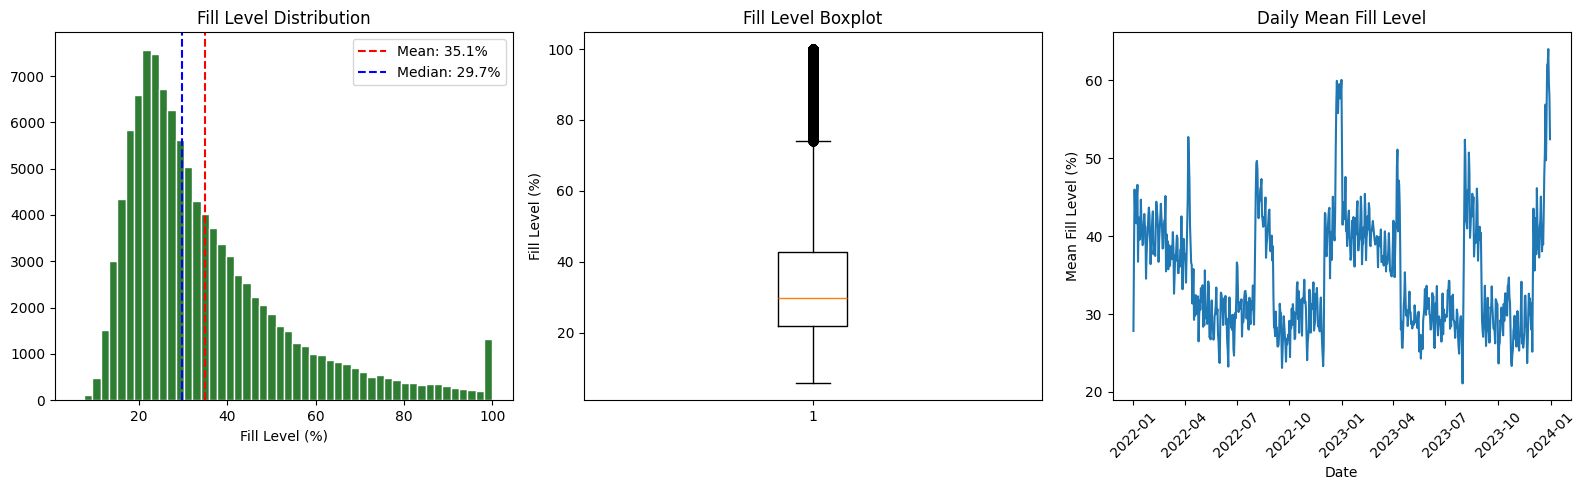

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#  Histogram Distribution
axes[0].hist(df['fill_level_percent'], bins=50, color=colors['primary'], edgecolor='white')
axes[0].axvline(df['fill_level_percent'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["fill_level_percent"].mean():.1f}%')
axes[0].axvline(df['fill_level_percent'].median(), color='blue', linestyle='--',
                label=f'Median: {df["fill_level_percent"].median():.1f}%')
axes[0].set_xlabel('Fill Level (%)')
axes[0].set_title('Fill Level Distribution')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['fill_level_percent'], vert=True)
axes[1].set_title('Fill Level Boxplot')
axes[1].set_ylabel('Fill Level (%)')

# Trend over time (Line Chart)
df['collection_date'] = pd.to_datetime(df['collection_date'], errors='coerce')
daily = df.dropna(subset=['collection_date']).groupby(df['collection_date'].dt.date)['fill_level_percent'].mean()

axes[2].plot(daily.index, daily.values)
axes[2].set_title('Daily Mean Fill Level')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Mean Fill Level (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


#### **Summary**
Most bins are collected at low fill levels, with typical fill levels below 40%. The average is slightly higher than the median because a small number of bins occasionally reach very high fill levels. These high-fill cases are exceptions, not the norm.

The boxplot shows that normal operations are stable, while a few bins consistently stand out as high-risk. The time trend indicates predictable cycles, with short spikes caused by delayed or missed collections.

Overall, the system works well most of the time, but efficiency can be improved by focusing on high-risk bins and periods rather than using uniform, average-based collection rules.

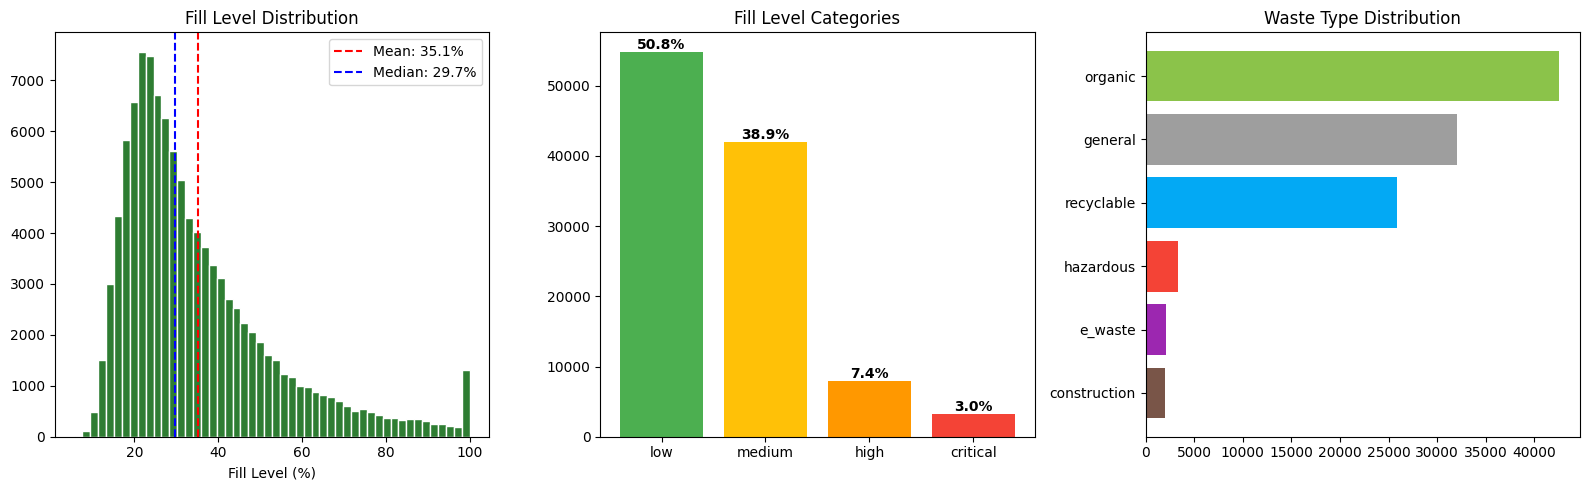


 Class Imbalance:
Fill Level - Majority: low (50.8%), Minority: critical (3.0%)
Waste Type - Majority: organic (39.4%), Minority: construction (1.9%)


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Fill Level Distribution
axes[0].hist(df['fill_level_percent'], bins=50, color=colors['primary'], edgecolor='white')
axes[0].axvline(df['fill_level_percent'].mean(), color='red', linestyle='--', label=f'Mean: {df["fill_level_percent"].mean():.1f}%')
axes[0].axvline(df['fill_level_percent'].median(), color='blue', linestyle='--', label=f'Median: {df["fill_level_percent"].median():.1f}%')
axes[0].set_xlabel('Fill Level (%)')
axes[0].set_title('Fill Level Distribution')
axes[0].legend()

# Fill Categories
cat_order = ['low', 'medium', 'high', 'critical']
fill_counts = df['fill_level_category'].value_counts().reindex(cat_order)
bars = axes[1].bar(fill_counts.index, fill_counts.values, color=[fill_colors[c] for c in cat_order])
for bar, val in zip(bars, fill_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Fill Level Categories')

# Waste Type
waste_counts = df['waste_type_primary'].value_counts()
axes[2].barh(waste_counts.index, waste_counts.values, color=[waste_colors.get(w, 'gray') for w in waste_counts.index])
axes[2].set_title('Waste Type Distribution')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/01_target_distributions.png', dpi=150)
plt.show()

print('\n Class Imbalance:')
print(f'Fill Level - Majority: {fill_counts.idxmax()} ({fill_counts.max()/len(df)*100:.1f}%), Minority: {fill_counts.idxmin()} ({fill_counts.min()/len(df)*100:.1f}%)')
print(f'Waste Type - Majority: {waste_counts.idxmax()} ({waste_counts.max()/len(df)*100:.1f}%), Minority: {waste_counts.idxmin()} ({waste_counts.min()/len(df)*100:.1f}%)')

## Fill Level By Location 

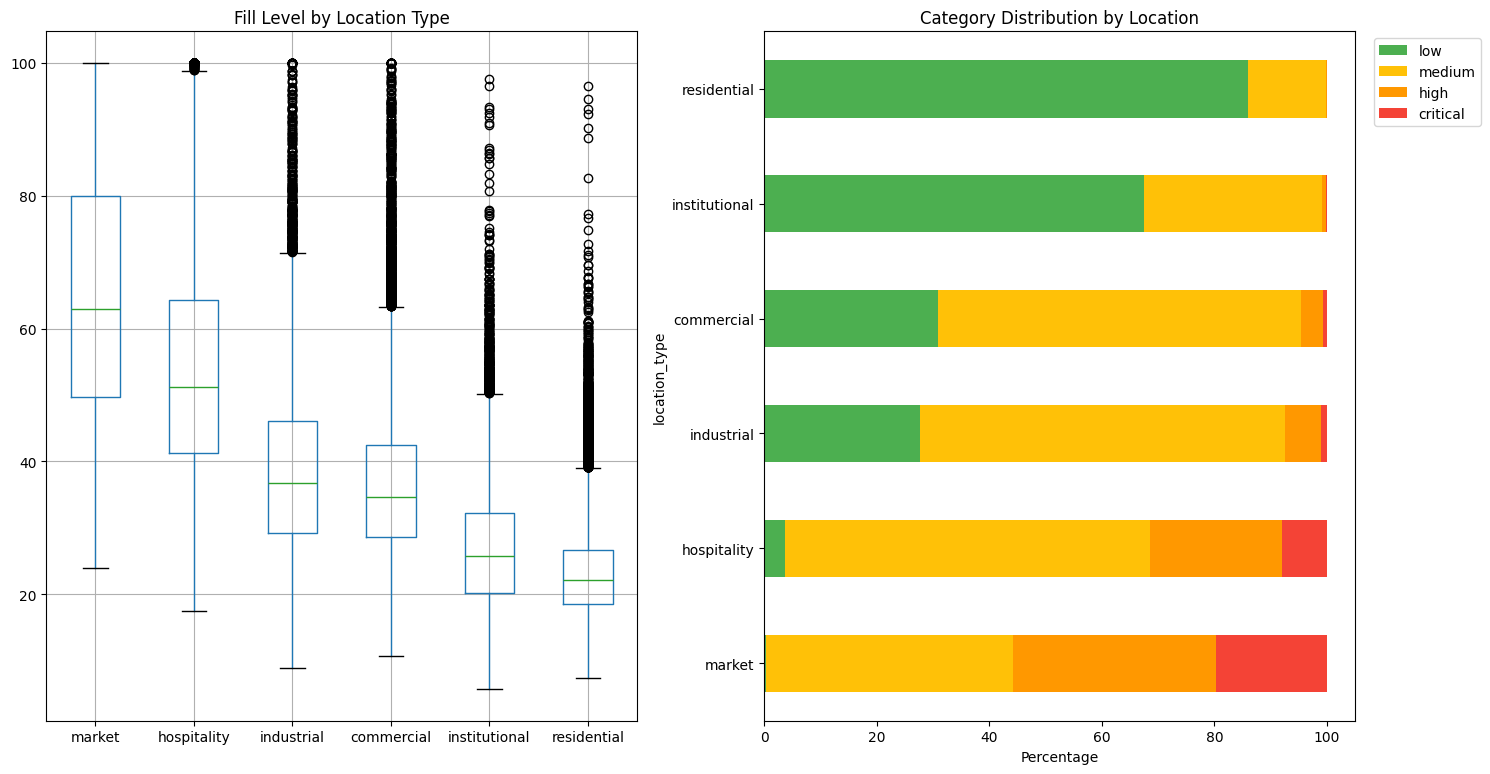


 Fill Level Statistics by Location:


,Mean %,Median %,Std,Count
location_type,,,,
market,65.47,63.0,19.14,10416
hospitality,54.43,51.2,17.59,10995
industrial,38.93,36.7,14.02,10304
commercial,36.85,34.7,12.17,20650
institutional,26.97,25.7,9.94,14014
residential,23.23,22.2,7.08,41570


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

location_order = df.groupby('location_type')['fill_level_percent'].median().sort_values(ascending=False).index

df_plt = df.copy()
df_plt['location_type'] = pd.Categorical (df_plt['location_type'], categories=location_order, 
                                          ordered=True)
df_plt.boxplot(column='fill_level_percent', by='location_type', ax=axes[0])
axes[0].set_title('Fill Level by Location Type')
axes[0].set_xlabel('')
plt.suptitle('')

# Stacked Bar 
crsstab = pd.crosstab(df['location_type'], df['fill_level_category'], normalize='index') * 100 
crsstab = crsstab.reindex(columns=['low', 'medium', 'high', 'critical']).loc[location_order]
crsstab.plot(kind='barh', stacked=True, ax=axes[1],
             color=[fill_colors[c] for c in crsstab.columns])

axes[1].set_xlabel('Percentage')
axes[1].set_title('Category Distribution by Location')
axes[1].legend(bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/02_fill_by_location.png', dpi=150)
plt.show()

print('\n Fill Level Statistics by Location:')
stats = df.groupby('location_type')['fill_level_percent'].agg(['mean', 'median', 'std', 'count']).round(2)
stats.columns = ['Mean %', 'Median %', 'Std', 'Count']
display(stats.sort_values('Mean %', ascending=False))

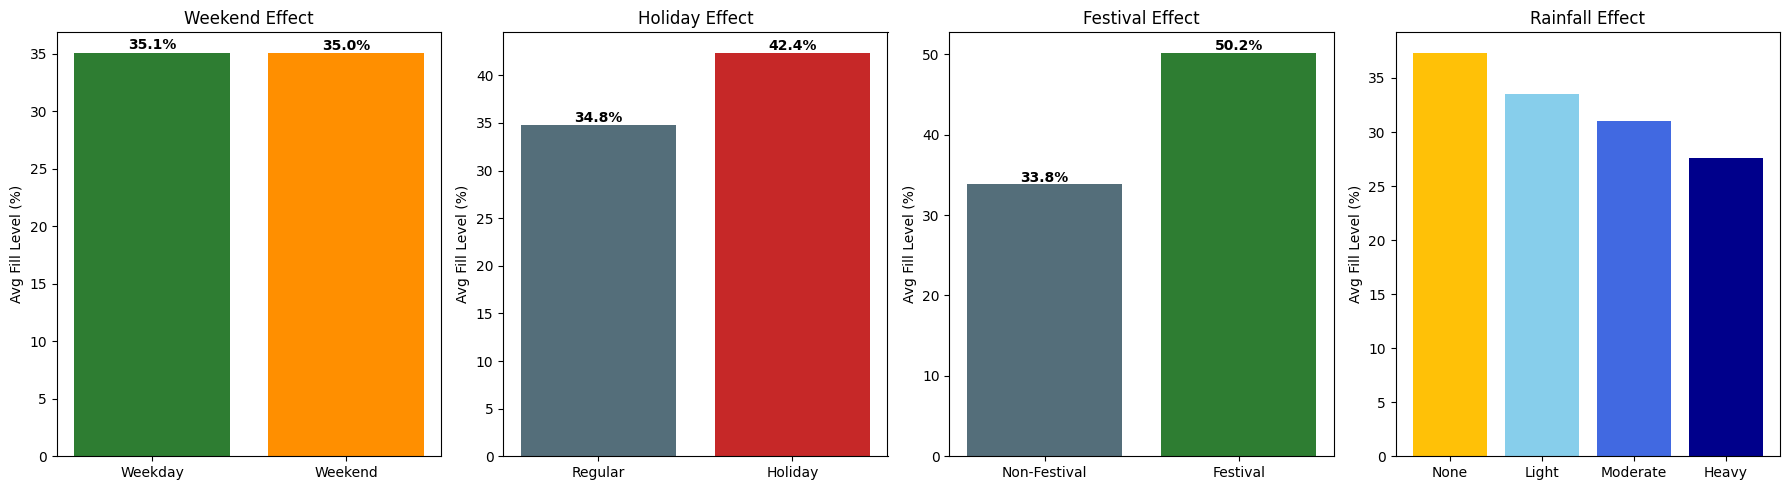


 Effect Summary:
Weekend Effect: -0.08%
Holiday Effect: +7.60%
Festival Effect: +16.39%


In [20]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

def plot_effect(ax, group_col, labels, colors, title):
    vals = df.groupby(group_col)['fill_level_percent'].mean()
    ax.bar(labels, vals.values, color=colors)
    for i, v in enumerate(vals.values):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel('Avg Fill Level (%)')
    return vals

# Weekend
weekend = plot_effect(axes[0], 'is_weekend', ['Weekday', 'Weekend'], [colors['primary'], colors['accent']], 'Weekend Effect')

# Holiday
holiday = plot_effect(axes[1], 'is_holiday', ['Regular', 'Holiday'], [colors['neutral'], colors['danger']], 'Holiday Effect')

# Festival
festival = plot_effect(axes[2], 'is_festival_period', ['Non-Festival', 'Festival'], [colors['neutral'], colors['primary']], 'Festival Effect')

# Rainfall
df['rain_cat'] = pd.cut(df['rainfall_mm'], bins=[-1, 0, 5, 20, 100], labels=['None', 'Light', 'Moderate', 'Heavy'])
rain_fill = df.groupby('rain_cat')['fill_level_percent'].mean()
axes[3].bar(rain_fill.index, rain_fill.values, color=['#FFC107', '#87CEEB', '#4169E1', '#00008B'])
axes[3].set_title('Rainfall Effect')
axes[3].set_ylabel('Avg Fill Level (%)')

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/04_special_events.png', dpi=150)
plt.show()

print('\n Effect Summary:')
print(f'Weekend Effect: {weekend[1] - weekend[0]:+.2f}%')
print(f'Holiday Effect: {holiday[1] - holiday[0]:+.2f}%')
print(f'Festival Effect: {festival[1] - festival[0]:+.2f}%')

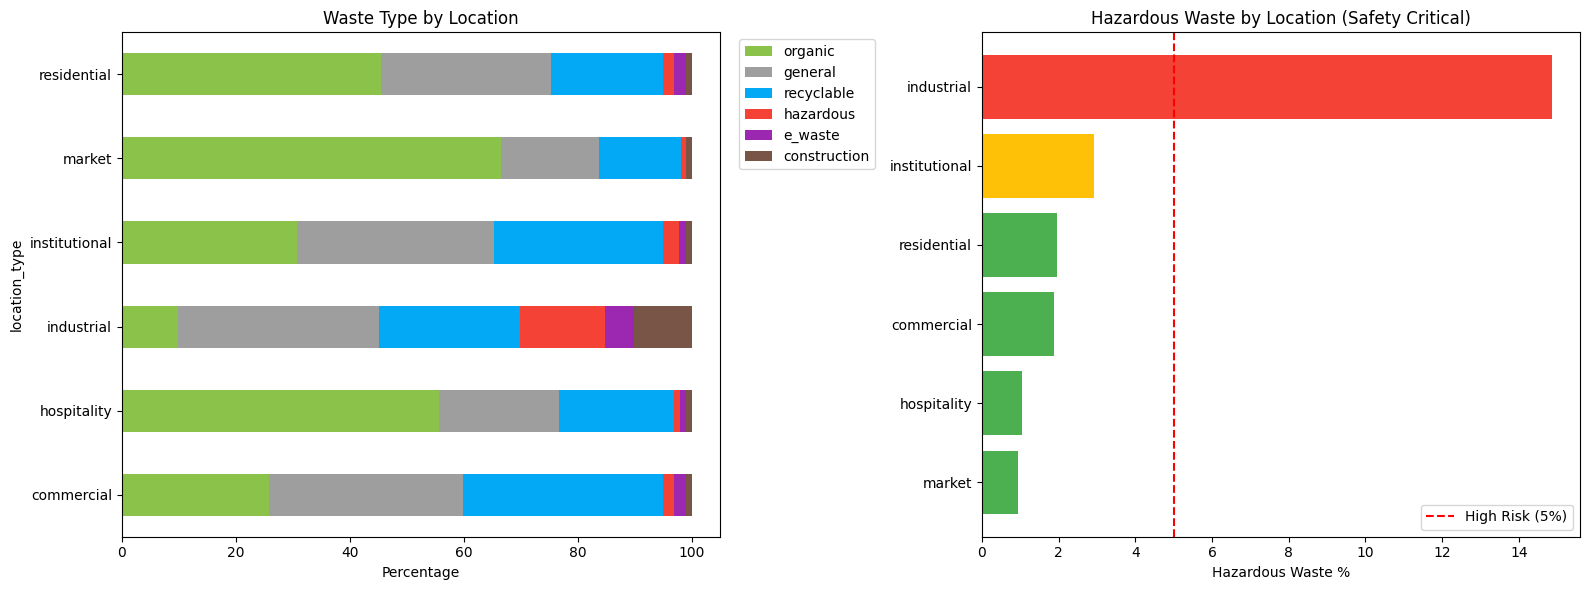


 Hazardous Waste Prevalence:
               Hazardous %
location_type             
industrial           14.85
institutional         2.93
residential           1.97
commercial            1.89
hospitality           1.04
market                0.94


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Waste type by location
ct_waste = pd.crosstab(df['location_type'], df['waste_type_primary'], normalize='index') * 100
waste_order = ['organic', 'general', 'recyclable', 'hazardous', 'e_waste', 'construction']
ct_waste = ct_waste.reindex(columns=[c for c in waste_order if c in ct_waste.columns])
ct_waste.plot(kind='barh', stacked=True, ax=axes[0], color=[waste_colors[w] for w in ct_waste.columns])
axes[0].set_xlabel('Percentage')
axes[0].set_title('Waste Type by Location')
axes[0].legend(bbox_to_anchor=(1.02, 1))

# Hazardous waste prevalence
haz_by_loc = df[df['waste_type_primary'] == 'hazardous'].groupby('location_type').size()
total_by_loc = df.groupby('location_type').size()
haz_pct = (haz_by_loc / total_by_loc * 100).fillna(0).sort_values()
colors = ['#F44336' if v > 5 else '#FFC107' if v > 2 else '#4CAF50' for v in haz_pct.values]
axes[1].barh(haz_pct.index, haz_pct.values, color=colors)
axes[1].axvline(5, color='red', linestyle='--', label='High Risk (5%)')
axes[1].set_xlabel('Hazardous Waste %')
axes[1].set_title('Hazardous Waste by Location (Safety Critical)')
axes[1].legend()

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/05_waste_type_analysis.png', dpi=150)
plt.show()

print('\n Hazardous Waste Prevalence:')
print(haz_pct.sort_values(ascending=False).round(2).to_frame('Hazardous %'))

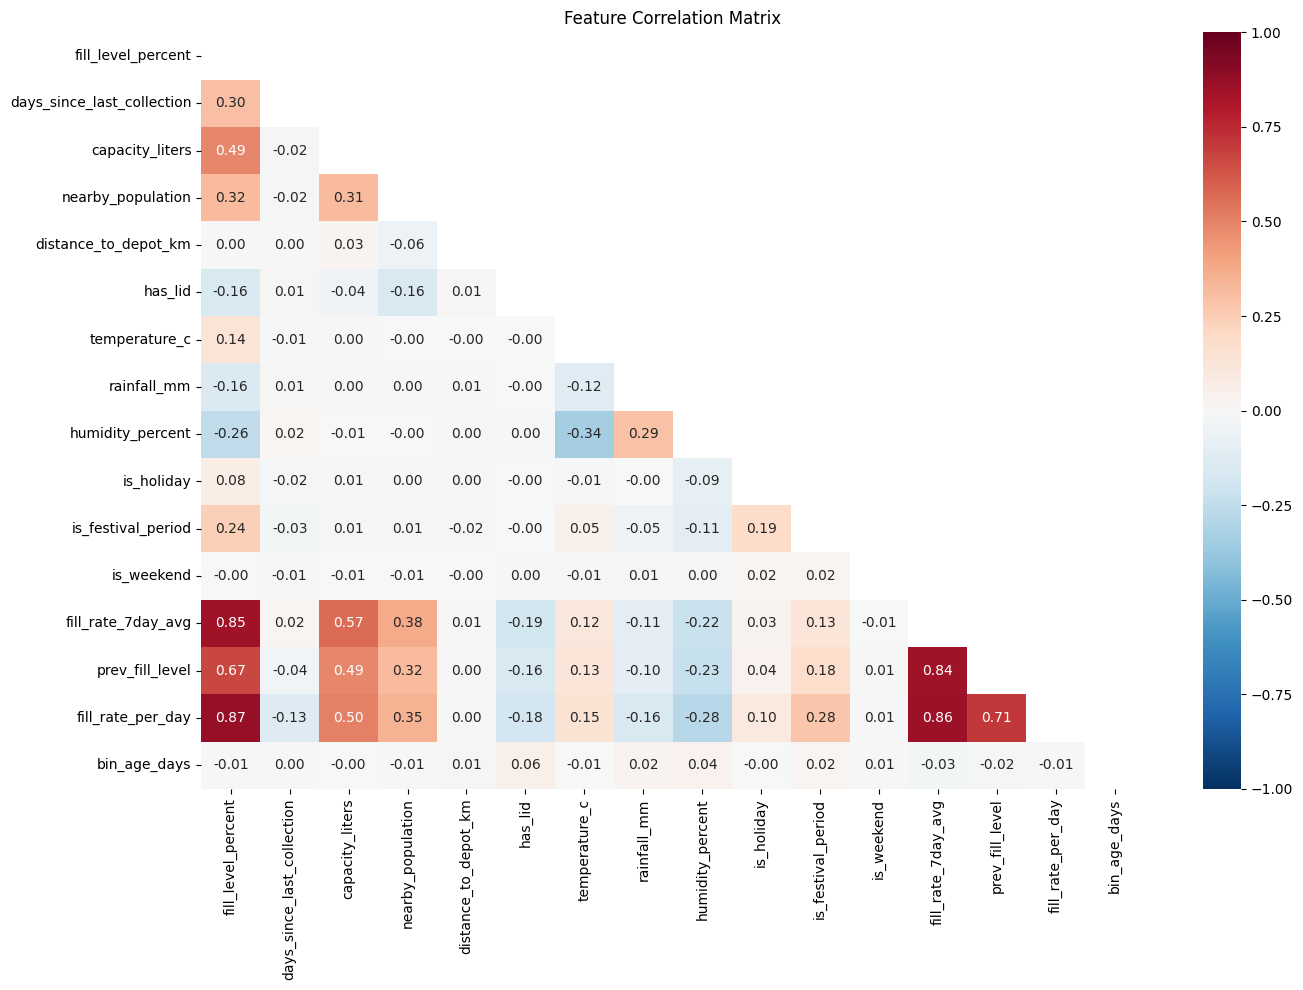


 Top Correlations with Fill Level:
                            Correlation
fill_rate_per_day                 0.875
fill_rate_7day_avg                0.847
prev_fill_level                   0.669
capacity_liters                   0.487
nearby_population                 0.320
days_since_last_collection        0.303
humidity_percent                 -0.255
is_festival_period                0.236
has_lid                          -0.163
rainfall_mm                      -0.155


In [22]:
num_cols = ['fill_level_percent', 'days_since_last_collection', 'capacity_liters', 'nearby_population',
            'distance_to_depot_km', 'has_lid', 'temperature_c', 'rainfall_mm', 'humidity_percent',
            'is_holiday', 'is_festival_period', 'is_weekend', 'fill_rate_7day_avg', 'prev_fill_level',
            'fill_rate_per_day', 'bin_age_days']
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/06_correlation_matrix.png', dpi=150)
plt.show()

# Top correlations with target
tget_corr = corr['fill_level_percent'].drop('fill_level_percent').sort_values(key=abs, ascending=False)
print('\n Top Correlations with Fill Level:')
print(tget_corr.round(3).head(10).to_frame('Correlation'))

## Key Relationship

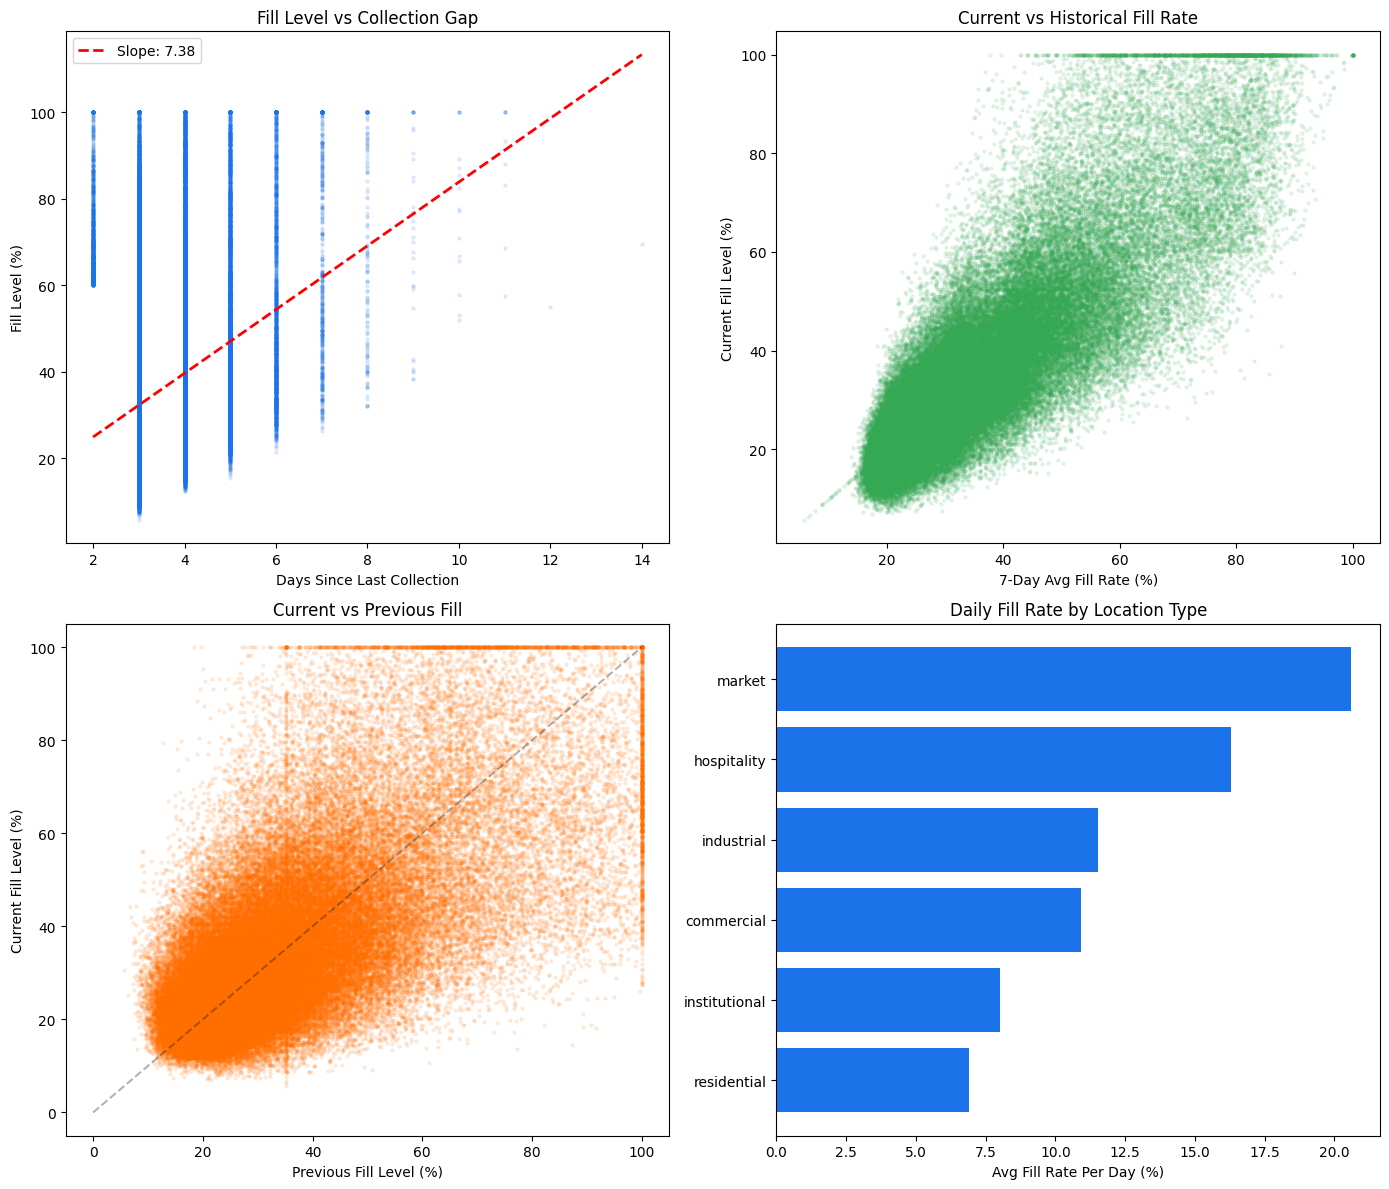

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Days vs Fill Level
axes[0, 0].scatter(df['days_since_last_collection'], df['fill_level_percent'], alpha=0.1, s=5, c='#1a73e8')
z = np.polyfit(df['days_since_last_collection'], df['fill_level_percent'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['days_since_last_collection'].min(), df['days_since_last_collection'].max(), 100)
axes[0, 0].plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Slope: {z[0]:.2f}')
axes[0, 0].set_xlabel('Days Since Last Collection')
axes[0, 0].set_ylabel('Fill Level (%)')
axes[0, 0].set_title('Fill Level vs Collection Gap')
axes[0, 0].legend()

# 7-day avg vs current
axes[0, 1].scatter(df['fill_rate_7day_avg'], df['fill_level_percent'], alpha=0.1, s=5, c='#34a853')
axes[0, 1].set_xlabel('7-Day Avg Fill Rate (%)')
axes[0, 1].set_ylabel('Current Fill Level (%)')
axes[0, 1].set_title('Current vs Historical Fill Rate')

# Previous vs current
axes[1, 0].scatter(df['prev_fill_level'], df['fill_level_percent'], alpha=0.1, s=5, c='#ff6f00')
axes[1, 0].plot([0, 100], [0, 100], 'k--', alpha=0.3)
axes[1, 0].set_xlabel('Previous Fill Level (%)')
axes[1, 0].set_ylabel('Current Fill Level (%)')
axes[1, 0].set_title('Current vs Previous Fill')

# Fill rate per day by location
loc_fillrate = df.groupby('location_type')['fill_rate_per_day'].mean().sort_values(ascending=True)
axes[1, 1].barh(loc_fillrate.index, loc_fillrate.values, color='#1a73e8')
axes[1, 1].set_xlabel('Avg Fill Rate Per Day (%)')
axes[1, 1].set_title('Daily Fill Rate by Location Type')

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/07_key_relationships.png', dpi=150)
plt.show()

## Summary
Bins fill at approximately 7% per day on average, with markets filling 3× faster than residential areas.  Historical fill patterns strongly predict current levels, making fill_rate_7day_avg, days_since_last_collection, and location_type the most important features for modeling.

#### Business Insight
Focus collection resources on markets and hospitality areas first, they fill up 3× faster and pose the highest overflow risk. Implementing location-based dynamic scheduling (frequent pickups for markets, less frequent for residential) could significantly reduce overflow incidents and optimize truck routes.

### **Incident Analysis**

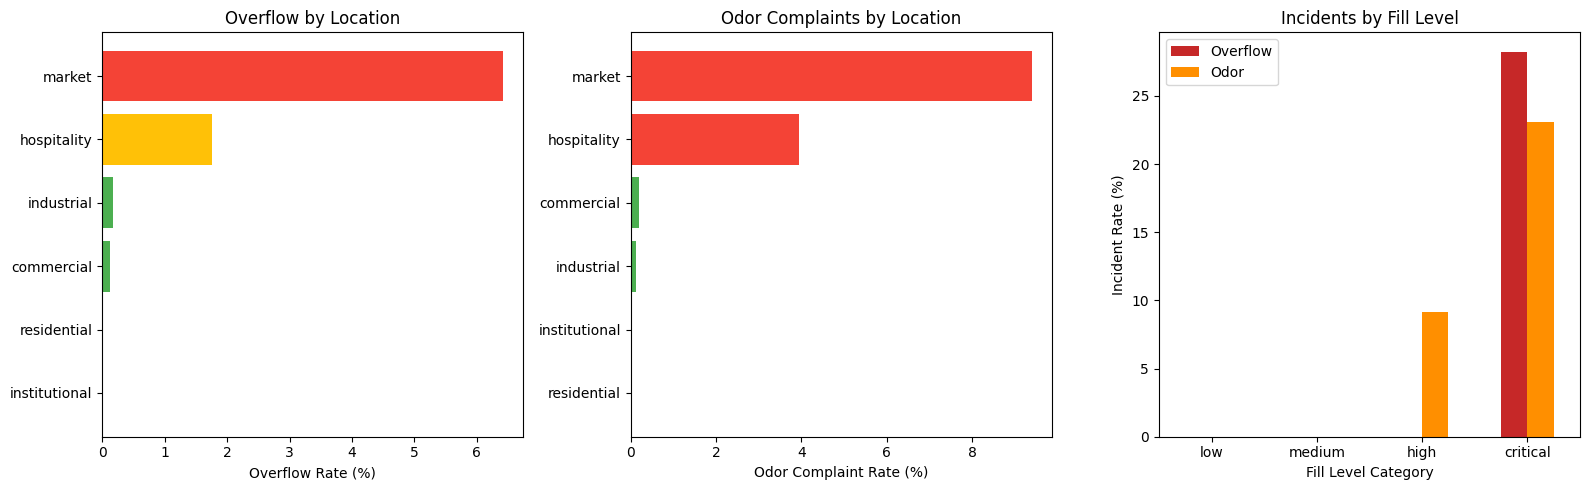


 Overall Incident Rates:
Overflow: 0.84%
Odor Complaints: 1.36%


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overflow by location
overflow_pct = (df.groupby('location_type')['overflow_reported'].mean() * 100).sort_values()
bar_colors = ['#F44336' if v > 2 else '#FFC107' if v > 1 else '#4CAF50' for v in overflow_pct.values]
axes[0].barh(overflow_pct.index, overflow_pct.values, color=bar_colors)
axes[0].set_xlabel('Overflow Rate (%)')
axes[0].set_title('Overflow by Location')

# Odor by location
odor_pct = (df.groupby('location_type')['odor_complaint'].mean() * 100).sort_values()
bar_colors = ['#F44336' if v > 3 else '#FFC107' if v > 1.5 else '#4CAF50' for v in odor_pct.values]
axes[1].barh(odor_pct.index, odor_pct.values, color=bar_colors)
axes[1].set_xlabel('Odor Complaint Rate (%)')
axes[1].set_title('Odor Complaints by Location')

# Incidents by fill category
cat_order = ['low', 'medium', 'high', 'critical']
incident_by_fill = df.groupby('fill_level_category')[['overflow_reported', 'odor_complaint']].mean() * 100
incident_by_fill = incident_by_fill.reindex(cat_order)
incident_by_fill.plot(kind='bar', ax=axes[2], color=['#C62828', '#FF8F00'])  # Fixed line
axes[2].set_xlabel('Fill Level Category')
axes[2].set_ylabel('Incident Rate (%)')
axes[2].set_title('Incidents by Fill Level')
axes[2].legend(['Overflow', 'Odor'])
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/08_incident_analysis.png', dpi=150)
plt.show()

print(f'\n Overall Incident Rates:')
print(f'Overflow: {df["overflow_reported"].mean()*100:.2f}%')
print(f'Odor Complaints: {df["odor_complaint"].mean()*100:.2f}%')

## **Geographic Distributions**

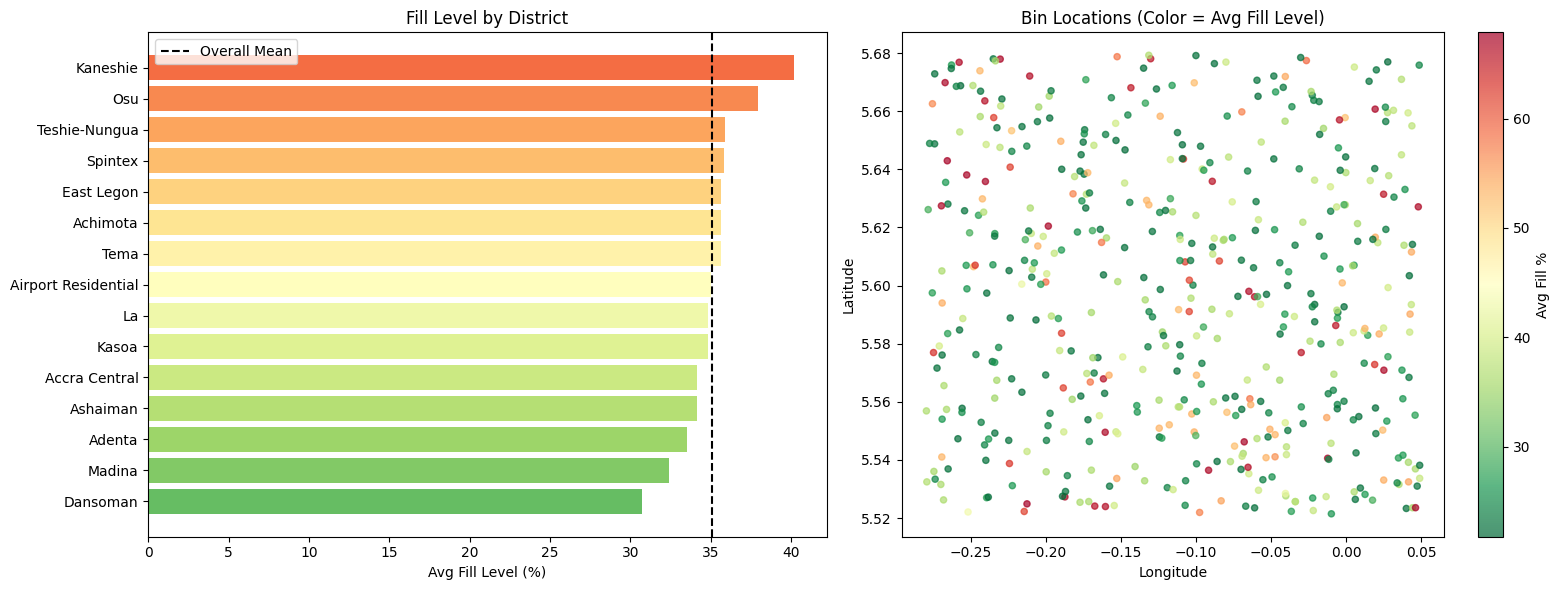

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fill by district
district_fill = df.groupby('district')['fill_level_percent'].mean().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(district_fill)))
axes[0].barh(district_fill.index, district_fill.values, color=colors)
axes[0].axvline(df['fill_level_percent'].mean(), color='black', linestyle='--', label='Overall Mean')
axes[0].set_xlabel('Avg Fill Level (%)')
axes[0].set_title('Fill Level by District')
axes[0].legend()

# Bin map
bin_stats = df.groupby('bin_id').agg({'fill_level_percent': 'mean', 'latitude': 'first', 'longitude': 'first'}).reset_index()
scatter = axes[1].scatter(bin_stats['longitude'], bin_stats['latitude'], c=bin_stats['fill_level_percent'], cmap='RdYlGn_r', s=20, alpha=0.7)
plt.colorbar(scatter, ax=axes[1], label='Avg Fill %')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Bin Locations (Color = Avg Fill Level)')

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/09_geographic.png', dpi=150)
plt.show()

Kaneshie and Osu districts need priority collection — they consistently have the highest fill levels. Dansoman and Madina are well-managed and could serve as models for other districts.

## **Business Insight:** 
Prioritize collection resources in Kaneshie and Osu districts — they have 40% higher fill levels than Dansoman and Madina. Reallocating just 1-2 trucks from low-fill districts to these hotspots could prevent overflows and reduce complaints without increasing overall fleet costs.